# Identificação de Regimes de Preços com Autoencoder

**Disciplina:** [NOME DA DISCIPLINA]

**Curso:** [NOME DO CURSO]

**Professor:** Renan Santos Mendes

**Email:** renansantosmendes@gmail.com

---

Este notebook adapta a abordagem de detecção de outliers para **identificação de
regimes** em uma série temporal financeira real, obtida com a biblioteca
`yfinance`.

A ideia central é a mesma do notebook de outliers (autoencoder treinado sobre
janelas deslizantes de log-retornos), mas usada de duas formas complementares:

- **Erro de reconstrução suavizado**: picos e patamares elevados sinalizam
  mudanças de regime (ex: transição para alta volatilidade).
- **Clustering no espaço latente**: o vetor latente de cada janela é agrupado
  (K-Means) em regimes, permitindo identificar não só *quando* o regime mudou,
  mas também *qual* regime está ativo em cada momento.

Os pontos de mudança de regime (changepoints) são então marcados sobre a
série de preços.

## Instalação das dependências

A célula abaixo instala as bibliotecas necessárias para a execução do
notebook no Google Colab, utilizando o `uv` como gerenciador de pacotes.

In [4]:
# !pip install -q uv
# !uv pip install --system -q yfinance torch matplotlib pandas numpy scikit-learn

## Importação das bibliotecas

A célula a seguir importa todas as bibliotecas utilizadas ao longo do
notebook e fixa as sementes de aleatoriedade, garantindo a
reprodutibilidade dos resultados.

In [5]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

torch.manual_seed(42)
np.random.seed(42)

## Carregamento da série financeira

A função `fetch_price_series` faz o download dos preços de fechamento
ajustados de um ativo financeiro utilizando o `yfinance`, para o
intervalo de datas informado.

In [6]:
def fetch_price_series(
    ticker: str,
    start_date: str,
    end_date: str,
) -> pd.Series:
    """Download the adjusted close price series for a given ticker.

    Args:
        ticker: The stock or asset ticker symbol (e.g. "AAPL").
        start_date: The start date of the period, in "YYYY-MM-DD"
            format.
        end_date: The end date of the period, in "YYYY-MM-DD" format.

    Returns:
        A pandas Series containing the adjusted close price indexed
        by date, with missing values removed.
    """
    data = yf.download(
        ticker,
        start=start_date,
        end=end_date,
        auto_adjust=True,
    )
    data = data.dropna()
    return data["Close"].squeeze()

A célula abaixo define os parâmetros do ativo a ser analisado e executa o download da série de preços.

In [7]:
TICKER = "AAPL"
START_DATE = "2020-01-01"
END_DATE = "2026-01-01"

price = fetch_price_series(TICKER, START_DATE, END_DATE)

[*********************100%***********************]  1 of 1 completed


## Construção do dataframe de retornos

A função `build_return_dataframe` calcula os log-retornos diários a
partir da série de preços e organiza os dados em um `DataFrame` com as
colunas de data, retorno e preço.

In [8]:
def build_return_dataframe(price_series: pd.Series) -> pd.DataFrame:
    """Build a dataframe of log returns from a price series.

    Args:
        price_series: A pandas Series of asset prices indexed by
            date.

    Returns:
        A DataFrame with the columns "date", "return" and "price",
        where "return" contains the daily log returns and "price"
        contains the price aligned with each return.
    """
    log_returns = np.log(price_series).diff().dropna()
    return pd.DataFrame(
        {
            "date": log_returns.index,
            "return": log_returns.values,
            "price": price_series.loc[log_returns.index].values,
        }
    ).reset_index(drop=True)

In [9]:
df = build_return_dataframe(price)
number_of_observations = len(df)

print(
    f"Ticker: {TICKER} | Observacoes: {number_of_observations} | "
    f"Periodo: {df['date'].min().date()} a {df['date'].max().date()}"
)

Ticker: AAPL | Observacoes: 1507 | Periodo: 2020-01-03 a 2025-12-31


## Construção das janelas deslizantes

O autoencoder recebe como entrada janelas deslizantes dos retornos
diários. A função `create_sliding_windows` transforma a série de
retornos em uma matriz de janelas de tamanho fixo.

In [10]:
def create_sliding_windows(
    series: np.ndarray,
    window_size: int,
) -> np.ndarray:
    """Create sliding windows over a one-dimensional array.

    Args:
        series: A one-dimensional array containing the values to be
            windowed.
        window_size: The number of consecutive values in each
            window.

    Returns:
        A two-dimensional array of shape
        (len(series) - window_size + 1, window_size), where each row
        is a consecutive slice of the input series.

    Example:
        >>> create_sliding_windows(np.array([1, 2, 3, 4]), 2)
        array([[1, 2],
               [2, 3],
               [3, 4]])
    """
    number_of_windows = len(series) - window_size + 1
    return np.array(
        [series[index:index + window_size] for index in range(number_of_windows)]
    )

In [11]:
WINDOW_SIZE = 20

raw_windows = create_sliding_windows(df["return"].values, WINDOW_SIZE)

windows_mean = raw_windows.mean()
windows_std = raw_windows.std()
normalized_windows = (raw_windows - windows_mean) / windows_std

windows_tensor = torch.tensor(normalized_windows, dtype=torch.float32)

Nota: aqui usamos uma janela um pouco maior (20 dias, cerca de um mes de
pregao) do que no notebook de outliers. Para identificar *regime* faz sentido
olhar para um trecho mais longo de historico, e nao apenas para choques
pontuais de 1-2 dias.

## Autoencoder manual com PyTorch

A classe `SimpleAutoencoder` implementa um autoencoder simples,
composto por um codificador e um decodificador com camadas lineares e
ativacao `ReLU`. Diferente do notebook de outliers, aqui o espaco
latente e mantido em **2 dimensoes**: isso permite tanto agrupar as
janelas em regimes (K-Means) quanto visualizar o espaco latente
diretamente, sem precisar de uma reducao de dimensionalidade adicional.

In [12]:
class SimpleAutoencoder(nn.Module):
    """A simple fully connected autoencoder.

    The network is composed of an encoder that compresses the input
    into a lower-dimensional latent representation, and a decoder
    that reconstructs the original input from that representation.

    Attributes:
        encoder: The sequential module that encodes the input into
            the latent space.
        decoder: The sequential module that reconstructs the input
            from the latent space.
    """

    def __init__(
        self,
        input_dim: int,
        hidden_dim: int = 16,
        latent_dim: int = 2,
    ) -> None:
        """Initialize the encoder and decoder layers.

        Args:
            input_dim: The dimensionality of the input features.
            hidden_dim: The number of units in the hidden layers.
            latent_dim: The dimensionality of the latent
                representation.
        """
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
        )

    def forward(self, input_tensor: torch.Tensor) -> torch.Tensor:
        """Run the forward pass through the autoencoder.

        Args:
            input_tensor: A tensor of shape (batch_size, input_dim)
                containing the input features.

        Returns:
            A tensor of shape (batch_size, input_dim) containing the
            reconstructed input.
        """
        latent_representation = self.encoder(input_tensor)
        return self.decoder(latent_representation)

    def encode(self, input_tensor: torch.Tensor) -> torch.Tensor:
        """Return only the latent representation for the input.

        Args:
            input_tensor: A tensor of shape (batch_size, input_dim).

        Returns:
            A tensor of shape (batch_size, latent_dim).
        """
        return self.encoder(input_tensor)

A funcao `train_autoencoder` executa o laco de treinamento do autoencoder em PyTorch, utilizando o otimizador `Adam` e o erro quadratico medio como funcao de perda.

In [13]:
def train_autoencoder(
    model: nn.Module,
    input_tensor: torch.Tensor,
    num_epochs: int,
    learning_rate: float,
) -> nn.Module:
    """Train an autoencoder using mean squared error reconstruction loss.

    Args:
        model: The autoencoder model to be trained.
        input_tensor: A tensor containing the training data, where
            each row is an input sample.
        num_epochs: The number of training epochs.
        learning_rate: The learning rate used by the Adam optimizer.

    Returns:
        The trained autoencoder model.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss(reduction="none")

    model.train()
    for epoch in range(num_epochs):
        optimizer.zero_grad()
        reconstruction = model(input_tensor)
        loss = criterion(reconstruction, input_tensor).mean()
        loss.backward()
        optimizer.step()
        if (epoch + 1) % 30 == 0:
            print(f"[PyTorch AE] Epoch {epoch + 1}/{num_epochs} - loss: {loss.item():.5f}")

    return model

A funcao `compute_reconstruction_scores` calcula, para cada amostra, o erro medio de reconstrucao do autoencoder ja treinado.

In [14]:
def compute_reconstruction_scores(
    model: nn.Module,
    input_tensor: torch.Tensor,
) -> np.ndarray:
    """Compute per-sample reconstruction error scores.

    Args:
        model: A trained autoencoder model.
        input_tensor: A tensor containing the samples to be scored.

    Returns:
        A one-dimensional numpy array with the mean squared
        reconstruction error for each sample.
    """
    criterion = nn.MSELoss(reduction="none")
    model.eval()
    with torch.no_grad():
        reconstruction = model(input_tensor)
        errors = criterion(reconstruction, input_tensor).mean(dim=1)
    return errors.cpu().numpy()

In [15]:
device = "cuda" if torch.cuda.is_available() else "cpu"
windows_tensor = windows_tensor.to(device)

torch_model = SimpleAutoencoder(input_dim=WINDOW_SIZE).to(device)
torch_model = train_autoencoder(
    torch_model,
    windows_tensor,
    num_epochs=300,
    learning_rate=1e-3,
)

reconstruction_scores = compute_reconstruction_scores(torch_model, windows_tensor)

with torch.no_grad():
    latent_vectors = torch_model.encode(windows_tensor).cpu().numpy()

c:\00 - Source Codes\financial_market_simulator\.venv\Lib\site-packages\torch\cuda\__init__.py:188: UserWarning: cudaGetDeviceCount() returned cudaErrorNotSupported, likely using older driver or on CPU machine (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\c10\cuda\CUDAFunctions.cpp:88.)
  return torch._C._cuda_getDeviceCount() > 0


[PyTorch AE] Epoch 30/300 - loss: 1.00275
[PyTorch AE] Epoch 60/300 - loss: 0.97062
[PyTorch AE] Epoch 90/300 - loss: 0.92036
[PyTorch AE] Epoch 120/300 - loss: 0.88224
[PyTorch AE] Epoch 150/300 - loss: 0.85972
[PyTorch AE] Epoch 180/300 - loss: 0.84682
[PyTorch AE] Epoch 210/300 - loss: 0.83721
[PyTorch AE] Epoch 240/300 - loss: 0.83126
[PyTorch AE] Epoch 270/300 - loss: 0.82700
[PyTorch AE] Epoch 300/300 - loss: 0.82384


## Alinhamento dos indices

Como cada janela termina em uma posicao diferente da serie original,
e necessario mapear os escores e os regimes das janelas de volta para
os indices correspondentes no `DataFrame` de retornos.

In [16]:
window_end_indices = np.arange(WINDOW_SIZE - 1, number_of_observations)

## Sinal 1: erro de reconstrucao suavizado

O erro de reconstrucao bruto e ruidoso janela a janela. Para usa-lo como
indicador de regime, aplicamos uma media movel de suavizacao e definimos um
limiar (percentil do proprio erro) acima do qual consideramos que a serie
esta em um regime de "estresse" (maior dificuldade de reconstrucao, tipico de
alta volatilidade ou mudancas estruturais).

Os **changepoints** desse sinal binario (normal -> estresse ou estresse ->
normal) sao os pontos de mudanca de regime.

In [17]:
SMOOTHING_WINDOW = 10
STRESS_PERCENTILE = 90

smoothed_scores = (
    pd.Series(reconstruction_scores)
    .rolling(SMOOTHING_WINDOW, min_periods=1)
    .mean()
    .values
)

stress_threshold = np.percentile(smoothed_scores, STRESS_PERCENTILE)
stress_regime = (smoothed_scores > stress_threshold).astype(int)

# Changepoints: posicoes em que o regime (0/1) muda em relacao ao passo anterior
error_changepoints = np.where(np.diff(stress_regime) != 0)[0] + 1
error_changepoint_indices = window_end_indices[error_changepoints]

## Sinal 2: clustering no espaco latente

Alem do erro de reconstrucao, agrupamos os vetores latentes de cada janela
com **K-Means**. Antes do clustering, os vetores latentes sao suavizados com
uma media movel (mesma janela usada para suavizar o erro de reconstrucao),
para que o regime reflita uma persistencia real ao longo de dias/semanas, e
nao a oscilacao de uma janela para a outra. Cada cluster representa um
regime distinto de dinamica de retornos (ex: baixa volatilidade / alta
volatilidade / tendencia definida). Em seguida, aplicamos um filtro de
maioria (majority vote) sobre a sequencia de rotulos, para que o regime so
mude quando houver uma alteracao sustentada, e nao uma oscilacao pontual do
K-Means perto da fronteira entre clusters.

In [18]:
NUMBER_OF_REGIMES = 3

# Suavizamos o espaco latente (media movel) antes do clustering. Sem isso,
# o K-Means reage ao ruido janela a janela e produz um numero enorme de
# transicoes de regime irrealistas (o regime deveria ser um estado que
# persiste por dias/semanas, nao mudar a cada passo).
smoothed_latent_vectors = (
    pd.DataFrame(latent_vectors)
    .rolling(SMOOTHING_WINDOW, min_periods=1)
    .mean()
    .values
)

kmeans = KMeans(n_clusters=NUMBER_OF_REGIMES, random_state=42, n_init=10)
raw_regime_labels = kmeans.fit_predict(smoothed_latent_vectors)


def apply_majority_vote_filter(labels: np.ndarray, window: int) -> np.ndarray:
    """Smooth a sequence of discrete labels with a rolling majority vote.

    Even after smoothing the latent space, K-Means can still flip between
    neighboring clusters near their boundary, producing unrealistic
    day-to-day regime changes. This filter replaces each label with the
    most frequent label in a centered window around it, so a regime only
    changes when the label is consistently different for a sustained
    period.

    Args:
        labels: One-dimensional array of integer cluster labels.
        window: The size of the centered window used to compute the
            majority label.

    Returns:
        A one-dimensional array of the same length as `labels`, with
        each label replaced by the majority label in its neighborhood.
    """
    half_window = window // 2
    filtered = np.empty_like(labels)
    for index in range(len(labels)):
        start = max(0, index - half_window)
        end = min(len(labels), index + half_window + 1)
        values, counts = np.unique(labels[start:end], return_counts=True)
        filtered[index] = values[np.argmax(counts)]
    return filtered


regime_labels = apply_majority_vote_filter(raw_regime_labels, window=SMOOTHING_WINDOW * 2)

# Changepoints: posicoes em que o cluster (regime) muda em relacao ao passo anterior
cluster_changepoints = np.where(np.diff(regime_labels) != 0)[0] + 1
cluster_changepoint_indices = window_end_indices[cluster_changepoints]

print(f"Regimes (K-Means) identificados: {NUMBER_OF_REGIMES}")
print(f"Numero de transicoes de regime: {len(cluster_changepoint_indices)}")

Regimes (K-Means) identificados: 3
Numero de transicoes de regime: 30


## Grafico 1 - Pontos de mudanca de regime sobre a serie de precos

O grafico abaixo mostra a serie de precos com:

- **Fundo colorido**: regime identificado pelo K-Means no espaco latente,
  para cada dia coberto pelas janelas.
- **Linhas verticais tracejadas**: pontos de mudanca de regime (changepoints),
  tanto pelo criterio de erro de reconstrucao (estresse) quanto pelo criterio
  de cluster latente.

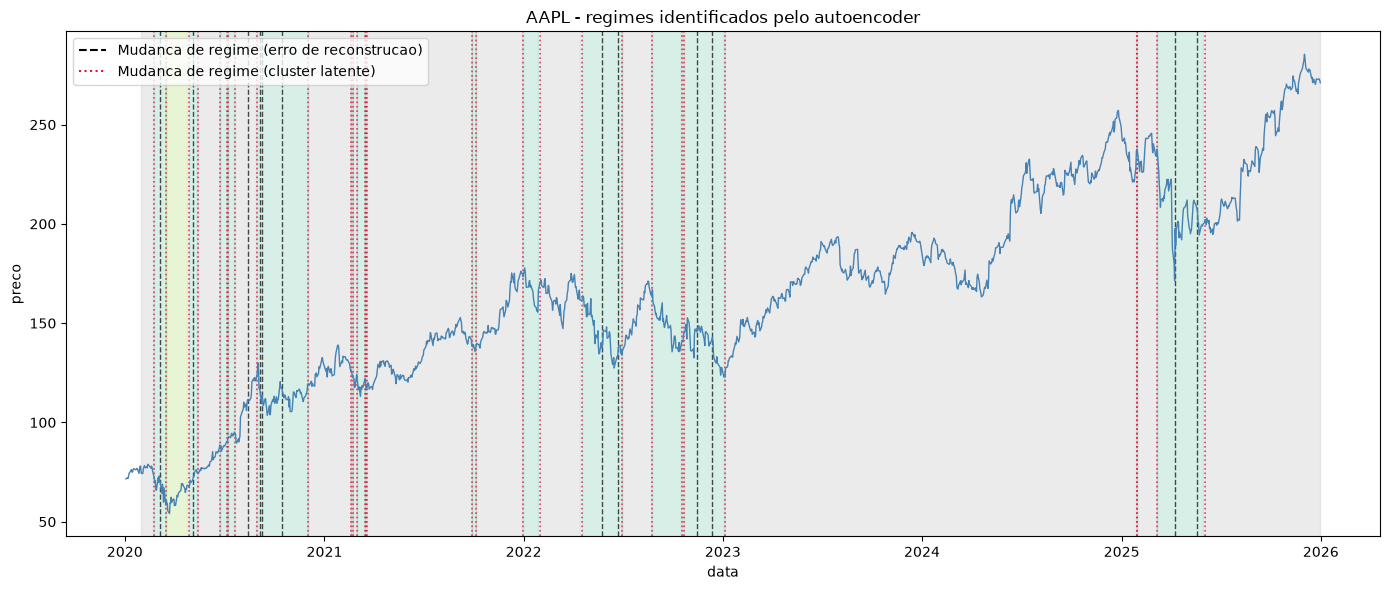

In [19]:
figure, axis = plt.subplots(figsize=(14, 6))

axis.plot(df["date"], df["price"], color="steelblue", linewidth=1, zorder=3)

# Fundo colorido por regime (cluster latente)
regime_colors = plt.cm.Set2(np.linspace(0, 1, NUMBER_OF_REGIMES))
dates_covered = df["date"].values[window_end_indices]

segment_start = 0
for step in range(1, len(regime_labels) + 1):
    is_last_step = step == len(regime_labels)
    regime_changed = (not is_last_step) and (regime_labels[step] != regime_labels[segment_start])
    if is_last_step or regime_changed:
        axis.axvspan(
            dates_covered[segment_start],
            dates_covered[step - 1],
            color=regime_colors[regime_labels[segment_start]],
            alpha=0.25,
            zorder=1,
        )
        segment_start = step

# Changepoints do erro de reconstrucao (regime de estresse)
for changepoint_index in error_changepoint_indices:
    axis.axvline(
        df["date"].values[changepoint_index],
        color="black",
        linestyle="--",
        linewidth=1,
        alpha=0.7,
        zorder=2,
    )

# Changepoints do cluster latente
for changepoint_index in cluster_changepoint_indices:
    axis.axvline(
        df["date"].values[changepoint_index],
        color="crimson",
        linestyle=":",
        linewidth=1.2,
        alpha=0.8,
        zorder=2,
    )

axis.plot([], [], color="black", linestyle="--", label="Mudanca de regime (erro de reconstrucao)")
axis.plot([], [], color="crimson", linestyle=":", label="Mudanca de regime (cluster latente)")
axis.set_title(f"{TICKER} - regimes identificados pelo autoencoder")
axis.set_xlabel("data")
axis.set_ylabel("preco")
axis.legend(loc="upper left")

plt.tight_layout()
plt.show()

## Grafico 2 - Erro de reconstrucao suavizado e limiar de estresse

Este grafico mostra diretamente o sinal usado no criterio de estresse: o
erro de reconstrucao suavizado ao longo do tempo, o limiar (percentil 90) e
os pontos onde a serie cruza esse limiar.

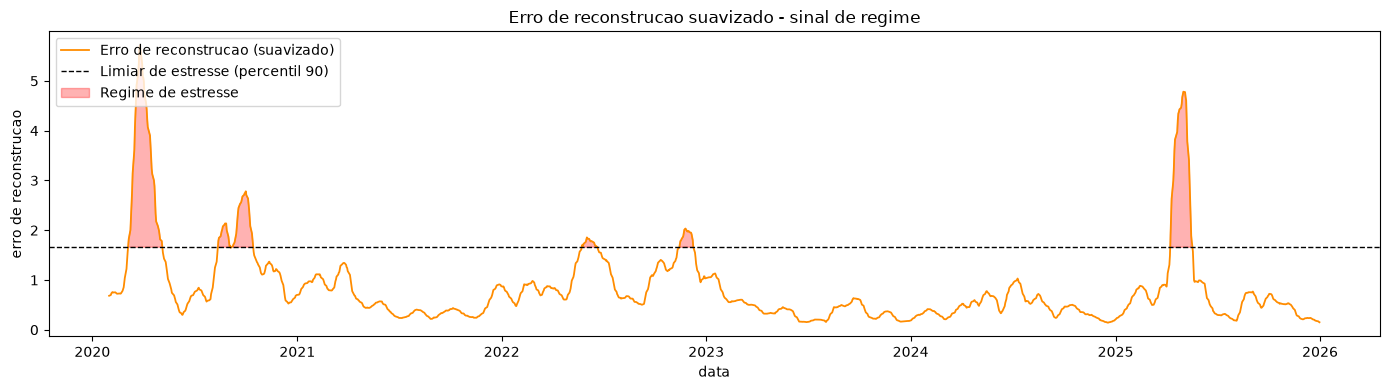

In [20]:
figure, axis = plt.subplots(figsize=(14, 4))

axis.plot(
    df["date"].values[window_end_indices],
    smoothed_scores,
    color="darkorange",
    linewidth=1.3,
    label="Erro de reconstrucao (suavizado)",
)
axis.axhline(
    stress_threshold,
    color="black",
    linestyle="--",
    linewidth=1,
    label=f"Limiar de estresse (percentil {STRESS_PERCENTILE})",
)
axis.fill_between(
    df["date"].values[window_end_indices],
    smoothed_scores,
    stress_threshold,
    where=(smoothed_scores > stress_threshold),
    color="red",
    alpha=0.3,
    label="Regime de estresse",
)
axis.set_title("Erro de reconstrucao suavizado - sinal de regime")
axis.set_xlabel("data")
axis.set_ylabel("erro de reconstrucao")
axis.legend(loc="upper left")

plt.tight_layout()
plt.show()

## Grafico 3 - Espaco latente colorido por regime

Por fim, visualizamos diretamente o espaco latente de 2 dimensoes aprendido
pelo autoencoder, colorindo cada janela pelo regime atribuido pelo K-Means.
Regimes bem separados no espaco latente indicam que o autoencoder aprendeu
uma representacao que discrimina bem as diferentes dinamicas de retorno.

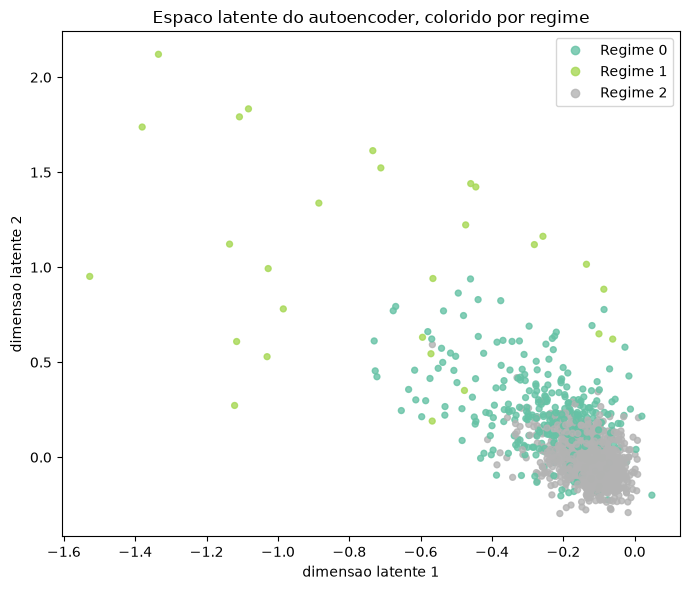

In [21]:
figure, axis = plt.subplots(figsize=(7, 6))

scatter = axis.scatter(
    smoothed_latent_vectors[:, 0],
    smoothed_latent_vectors[:, 1],
    c=regime_labels,
    cmap="Set2",
    s=18,
    alpha=0.8,
)
axis.set_title("Espaco latente do autoencoder, colorido por regime")
axis.set_xlabel("dimensao latente 1")
axis.set_ylabel("dimensao latente 2")

legend_handles = scatter.legend_elements()[0]
axis.legend(legend_handles, [f"Regime {i}" for i in range(NUMBER_OF_REGIMES)])

plt.tight_layout()
plt.show()

## Resumo dos regimes identificados

A tabela abaixo resume, para cada regime encontrado pelo K-Means, o numero de
janelas classificadas, o retorno medio e a volatilidade (desvio-padrao) dos
retornos dentro das janelas daquele regime - util para interpretar o que cada
regime representa (ex: "baixa volatilidade", "alta volatilidade",
"tendencia").

In [22]:
regime_summary_rows = []
window_returns = raw_windows  # janelas de retorno originais (nao normalizadas)

for regime_id in range(NUMBER_OF_REGIMES):
    mask = regime_labels == regime_id
    regime_summary_rows.append(
        {
            "regime": regime_id,
            "n_janelas": int(mask.sum()),
            "retorno_medio": window_returns[mask].mean(),
            "volatilidade_media": window_returns[mask].std(),
        }
    )

regime_summary = pd.DataFrame(regime_summary_rows).sort_values("volatilidade_media")
regime_summary

,regime,n_janelas,retorno_medio,volatilidade_media
2,2,1109,0.001774,0.015316
0,0,351,-0.001689,0.026592
1,1,28,-0.002763,0.056118
